In [1]:
import numpy as np

path = "./datasets/TemporalDrift/tam_valid.npz"
data = np.load(path)
print(data.files)

['X', 'y']


In [2]:
# 比如查看前5条
print(data['X'][:5])
print(data['y'][:5])

[[[  1.   0.   0. ...   0.   0.  31.]
  [  1.   0.   0. ...   0.   0.  22.]]

 [[  1.   0.   0. ...   0.   0. 100.]
  [  1.   0.   0. ...   0.   0.  13.]]

 [[  1.   0.   0. ...   0.   0.  72.]
  [  1.   0.   0. ...   0.   0.  33.]]

 [[  1.   0.   0. ...   0.   0.  18.]
  [  0.   0.   0. ...   0.   0.   9.]]

 [[  1.   0.   0. ...   0.   0. 152.]
  [  0.   0.   0. ...   0.   1.  94.]]]
[36. 59. 18. 79. 85.]


In [5]:
print(np.shape(data['X']))
print(np.shape(data['y']))

(2160, 2, 1800)
(2160,)


## 动机

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载所有数据：day14、day90、day270、原始训练集
# ======================
path = "./datasets/TemporalDrift/tam_train.npz"       # 原始流量
path14 = "./datasets/TemporalDrift/tam_day14.npz"     # day14
path90 = "./datasets/TemporalDrift/tam_day90.npz"     # day90
path270 = "./datasets/TemporalDrift/tam_day270.npz"   # day270

data = np.load(path)
data14 = np.load(path14)
data90 = np.load(path90)
data270 = np.load(path270)

X_s, y_s = data['X'], data['y']              # Source（原始）
X_t14, y_t14 = data14['X'], data14['y']     # day14
X_t90, y_t90 = data90['X'], data90['y']     # day90
X_t270, y_t270 = data270['X'], data270['y'] # day270

print("Source:", X_s.shape, y_s.shape)
print("Day14:", X_t14.shape, y_t14.shape)
print("Day90:", X_t90.shape, y_t90.shape)
print("Day270:", X_t270.shape, y_t270.shape)

# ======================
# 2. 只取类别 0
# ======================
cls = 0

X_s_cls = X_s[y_s == cls]
X_t14_cls = X_t14[y_t14 == cls]
X_t90_cls = X_t90[y_t90 == cls]
X_t270_cls = X_t270[y_t270 == cls]

# 统一样本数量，防止不一致
min_n = min(len(X_s_cls), len(X_t14_cls), len(X_t90_cls), len(X_t270_cls))
X_s_cls = X_s_cls[:min_n]
X_t14_cls = X_t14_cls[:min_n]
X_t90_cls = X_t90_cls[:min_n]
X_t270_cls = X_t270_cls[:min_n]

print("Class 0 samples (same length):", X_s_cls.shape, X_t14_cls.shape, X_t90_cls.shape, X_t270_cls.shape)

# ======================
# 3. FFT + log 幅度
# ======================
def get_spectrum(X):
    X_fft = np.fft.rfft(X, axis=2)
    X_mag = np.log1p(np.abs(X_fft))
    return X_mag

X_s_fft = get_spectrum(X_s_cls)
X_t14_fft = get_spectrum(X_t14_cls)
X_t90_fft = get_spectrum(X_t90_cls)
X_t270_fft = get_spectrum(X_t270_cls)

# ======================
# 4. 计算平均频谱
# ======================
mean_s = X_s_fft.mean(axis=0)
mean_t14 = X_t14_fft.mean(axis=0)
mean_t90 = X_t90_fft.mean(axis=0)
mean_t270 = X_t270_fft.mean(axis=0)

freq = np.arange(mean_s.shape[1])

# ======================
# 5. 绘图：4条曲线对比
# ======================
plt.figure(figsize=(10, 6))

# 绘制四条线
plt.plot(freq, mean_s[0], label='Source (Original)', linewidth=2.5)
plt.plot(freq, mean_t14[0], label='Day14', linewidth=2.5)
plt.plot(freq, mean_t90[0], label='Day90', linewidth=2.5)
plt.plot(freq, mean_t270[0], label='Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Log Magnitude")
plt.title("Class 0 Spectrum Comparison (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Source: (19439, 10000) (19439,)
Day14: (22603, 10000) (22603,)
Day90: (28599, 10000) (28599,)
Day270: (19935, 10000) (19935,)
Class 0 samples (same length): (194, 10000) (194, 10000) (194, 10000) (194, 10000)


IndexError: tuple index out of range

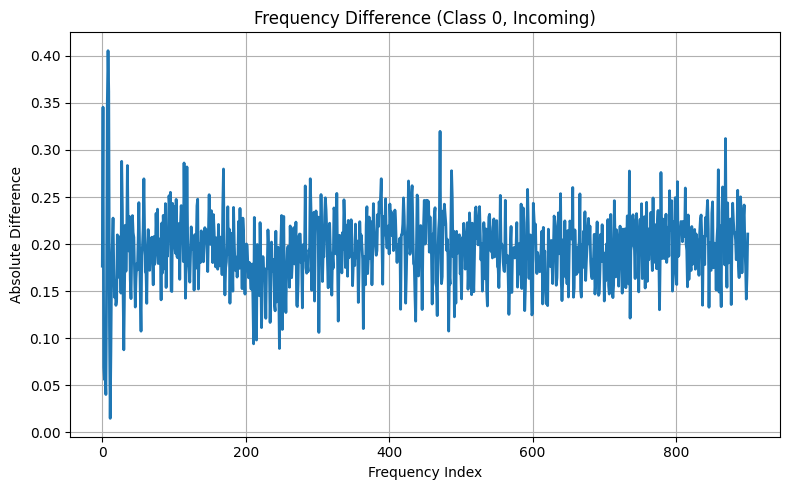

In [12]:
# ======================
# 6. 图2：频率差异（incoming）
# ======================
diff = np.abs(mean_s - mean_t)

plt.figure(figsize=(8, 5))

plt.plot(freq, diff[0], linewidth=2)

plt.xlabel("Frequency Index")
plt.ylabel("Absolute Difference")
plt.title("Frequency Difference (Class 0, Incoming)")
plt.grid()

plt.tight_layout()
plt.show()

In [13]:
# ======================
# 7. （可选）低频 vs 高频差异统计
# ======================
k = 100  # 低频范围

low_diff = diff[0][:k].mean()
high_diff = diff[0][k:].mean()

print(f"Low-frequency difference: {low_diff:.4f}")
print(f"High-frequency difference: {high_diff:.4f}")

Low-frequency difference: 0.1897
High-frequency difference: 0.1953


## 所以类别

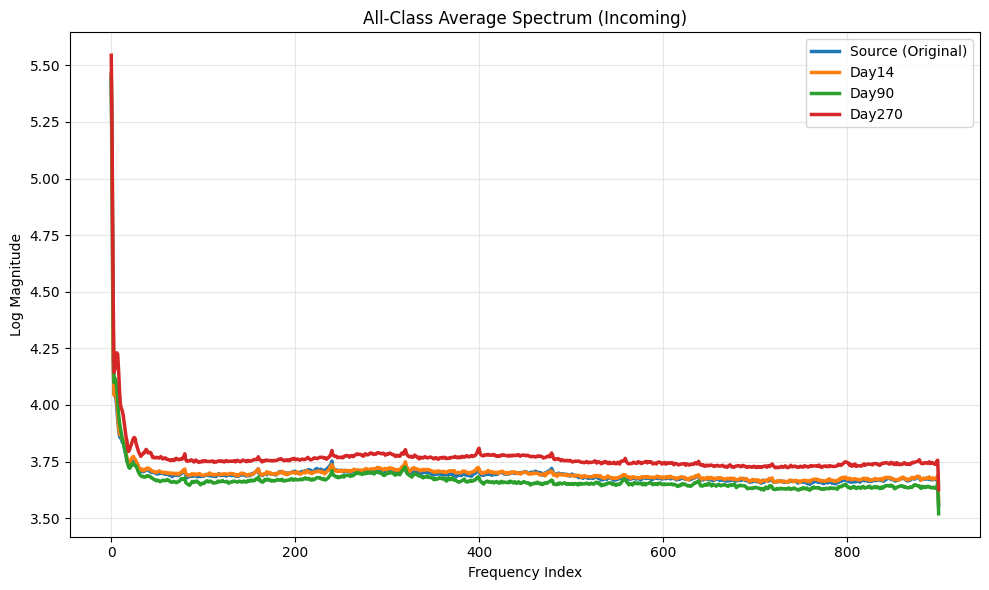

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载所有数据
# ======================
path = "./datasets/TemporalDrift/tam_train.npz"
path14 = "./datasets/TemporalDrift/tam_day14.npz"
path90 = "./datasets/TemporalDrift/tam_day90.npz"
path270 = "./datasets/TemporalDrift/tam_day270.npz"

data = np.load(path)
data14 = np.load(path14)
data90 = np.load(path90)
data270 = np.load(path270)

X_s, y_s = data['X'], data['y']
X_t14, y_t14 = data14['X'], data14['y']
X_t90, y_t90 = data90['X'], data90['y']
X_t270, y_t270 = data270['X'], data270['y']

# ======================
# 2. FFT 函数（只定义一次）
# ======================
def get_spectrum(X):
    X_fft = np.fft.rfft(X, axis=2)
    X_mag = np.log1p(np.abs(X_fft))
    return X_mag

# ======================
# 3. 遍历所有类别，计算平均频谱
# ======================
classes = np.unique(y_s)

all_mean_s = []
all_mean_t14 = []
all_mean_t90 = []
all_mean_t270 = []

for cls in classes:
    # 取出当前类别的样本
    X_s_cls = X_s[y_s == cls]
    X_t14_cls = X_t14[y_t14 == cls]
    X_t90_cls = X_t90[y_t90 == cls]
    X_t270_cls = X_t270[y_t270 == cls]

    # 统一最小样本数
    min_n = min(len(X_s_cls), len(X_t14_cls), len(X_t90_cls), len(X_t270_cls))
    X_s_cls = X_s_cls[:min_n]
    X_t14_cls = X_t14_cls[:min_n]
    X_t90_cls = X_t90_cls[:min_n]
    X_t270_cls = X_t270_cls[:min_n]

    # 计算频谱均值,同类所有曲线平均成一条代表曲线
    mean_s_cls = get_spectrum(X_s_cls).mean(axis=0)
    mean_t14_cls = get_spectrum(X_t14_cls).mean(axis=0)
    mean_t90_cls = get_spectrum(X_t90_cls).mean(axis=0)
    mean_t270_cls = get_spectrum(X_t270_cls).mean(axis=0)

    all_mean_s.append(mean_s_cls)
    all_mean_t14.append(mean_t14_cls)
    all_mean_t90.append(mean_t90_cls)
    all_mean_t270.append(mean_t270_cls)

# ======================
# 4. 所有类别整体平均
# ======================
mean_s_all = np.mean(all_mean_s, axis=0)
mean_t14_all = np.mean(all_mean_t14, axis=0)
mean_t90_all = np.mean(all_mean_t90, axis=0)
mean_t270_all = np.mean(all_mean_t270, axis=0)

freq = np.arange(mean_s_all.shape[1])

# ======================
# 5. 绘图：4条线对比
# ======================
plt.figure(figsize=(10, 6))

plt.plot(freq, mean_s_all[0], label='Source (Original)', linewidth=2.5)
plt.plot(freq, mean_t14_all[0], label='Day14', linewidth=2.5)
plt.plot(freq, mean_t90_all[0], label='Day90', linewidth=2.5)
plt.plot(freq, mean_t270_all[0], label='Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Log Magnitude")
plt.title("All-Class Average Spectrum (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

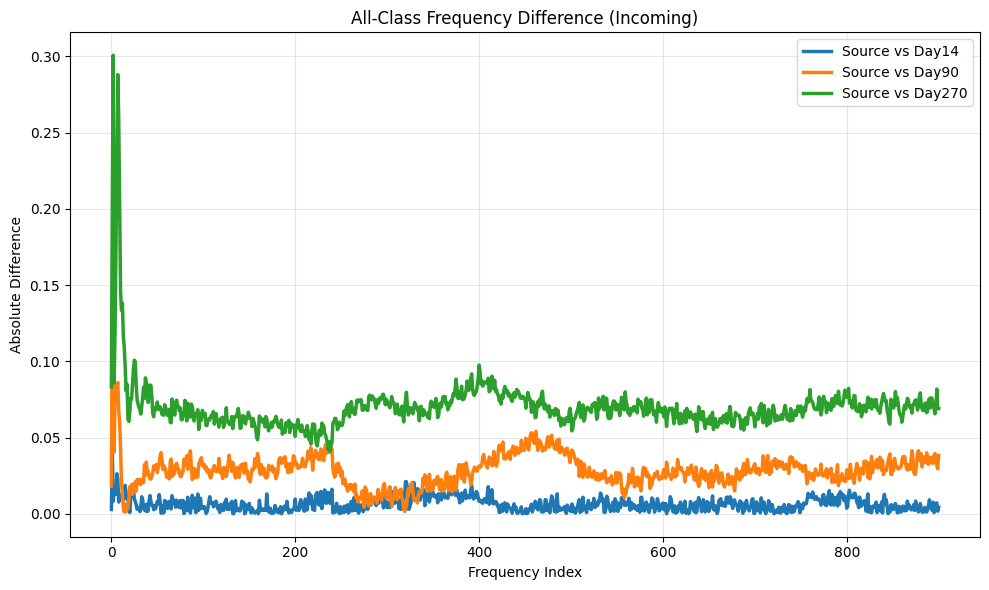

In [4]:
# ======================
# 5. 计算三条差值曲线（你要改的部分）
# ======================
diff_day14 = np.abs(mean_s_all - mean_t14_all)
diff_day90 = np.abs(mean_s_all - mean_t90_all)
diff_day270 = np.abs(mean_s_all - mean_t270_all)

# ======================
# 6. 绘制三条差值对比图
# ======================
plt.figure(figsize=(10, 6))
plt.plot(freq, diff_day14[0], label='Source vs Day14', linewidth=2.5)
plt.plot(freq, diff_day90[0], label='Source vs Day90', linewidth=2.5)
plt.plot(freq, diff_day270[0], label='Source vs Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Absolute Difference")
plt.title("All-Class Frequency Difference (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
k = 100  # 低频范围
low_diff = diff_all[0][:k].mean()
high_diff = diff_all[0][k:].mean()
print(f"Low-frequency difference: {low_diff:.4f}")
print(f"High-frequency difference: {high_diff:.4f}")

Low-frequency difference: 0.0865
High-frequency difference: 0.0678


# 新的频域转化

**不对,应该使用TAM之前的方向，大小序列，不然全是1和0为主的序列数据**

Class 0 samples: (194, 10000)


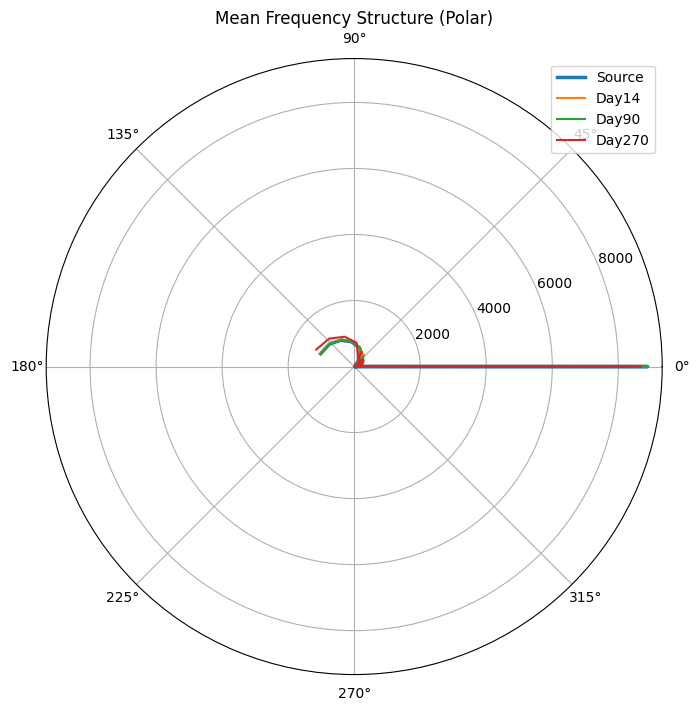

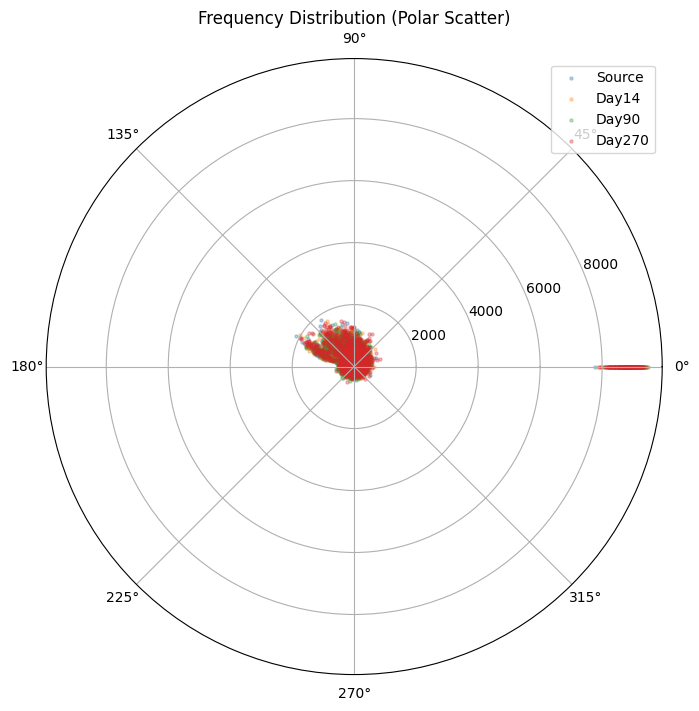

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载数据
# ======================
path = "./datasets/TemporalDrift/train.npz"
path14 = "./datasets/TemporalDrift/day14.npz"
path90 = "./datasets/TemporalDrift/day90.npz"
path270 = "./datasets/TemporalDrift/day270.npz"

data = np.load(path)
data14 = np.load(path14)
data90 = np.load(path90)
data270 = np.load(path270)

X_s, y_s = data['X'], data['y']
X_t14, y_t14 = data14['X'], data14['y']
X_t90, y_t90 = data90['X'], data90['y']
X_t270, y_t270 = data270['X'], data270['y']

# ======================
# 2. 只取类别 0
# ======================
cls = 0

X_s_cls = X_s[y_s == cls]
X_t14_cls = X_t14[y_t14 == cls]
X_t90_cls = X_t90[y_t90 == cls]
X_t270_cls = X_t270[y_t270 == cls]

# 对齐样本数量
min_n = min(len(X_s_cls), len(X_t14_cls), len(X_t90_cls), len(X_t270_cls))
X_s_cls = X_s_cls[:min_n]
X_t14_cls = X_t14_cls[:min_n]
X_t90_cls = X_t90_cls[:min_n]
X_t270_cls = X_t270_cls[:min_n]

print("Class 0 samples:", X_s_cls.shape)

# ======================
# 3. 频域特征
# ======================
def get_spectrum(X, modes=256):
    if X.ndim == 2:
        X = X[:, np.newaxis, :]   # (B,L) -> (B,1,L)

    X = np.cos(X)
    X_fft = np.fft.rfft(X, axis=-1)

    X_fft = X_fft[:, :, :modes]

    amp = np.abs(X_fft)
    phase = np.angle(X_fft)

    return amp, phase

modes = 256

amp_s, phase_s = get_spectrum(X_s_cls, modes)
amp_t14, phase_t14 = get_spectrum(X_t14_cls, modes)
amp_t90, phase_t90 = get_spectrum(X_t90_cls, modes)
amp_t270, phase_t270 = get_spectrum(X_t270_cls, modes)

# ======================
# 4. ===== 图1：平均结构（推荐先看）=====
# ======================
def mean_polar(amp, phase):
    amp_mean = amp.mean(axis=0)[0]
    phase_mean = phase.mean(axis=0)[0]

    idx = np.argsort(phase_mean)
    return phase_mean[idx], amp_mean[idx]

ps, as_ = mean_polar(amp_s, phase_s)
p14, a14 = mean_polar(amp_t14, phase_t14)
p90, a90 = mean_polar(amp_t90, phase_t90)
p270, a270 = mean_polar(amp_t270, phase_t270)

plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

ax.plot(ps, as_, label='Source', linewidth=2.5)
ax.plot(p14, a14, label='Day14')
ax.plot(p90, a90, label='Day90')
ax.plot(p270, a270, label='Day270')

ax.set_title("Mean Frequency Structure (Polar)")
ax.legend()
plt.show()

# ======================
# 5. ===== 图2：样本分布（核心）=====
# ======================
def sample_polar(amp, phase, sample_n=100):
    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp_s = amp[idx, 0, :]
    phase_s = phase[idx, 0, :]

    return phase_s.flatten(), amp_s.flatten()

ps, as_ = sample_polar(amp_s, phase_s)
p14, a14 = sample_polar(amp_t14, phase_t14)
p90, a90 = sample_polar(amp_t90, phase_t90)
p270, a270 = sample_polar(amp_t270, phase_t270)

plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

ax.scatter(ps, as_, s=5, alpha=0.3, label='Source')
ax.scatter(p14, a14, s=5, alpha=0.3, label='Day14')
ax.scatter(p90, a90, s=5, alpha=0.3, label='Day90')
ax.scatter(p270, a270, s=5, alpha=0.3, label='Day270')

ax.set_title("Frequency Distribution (Polar Scatter)")
ax.legend()
plt.show()

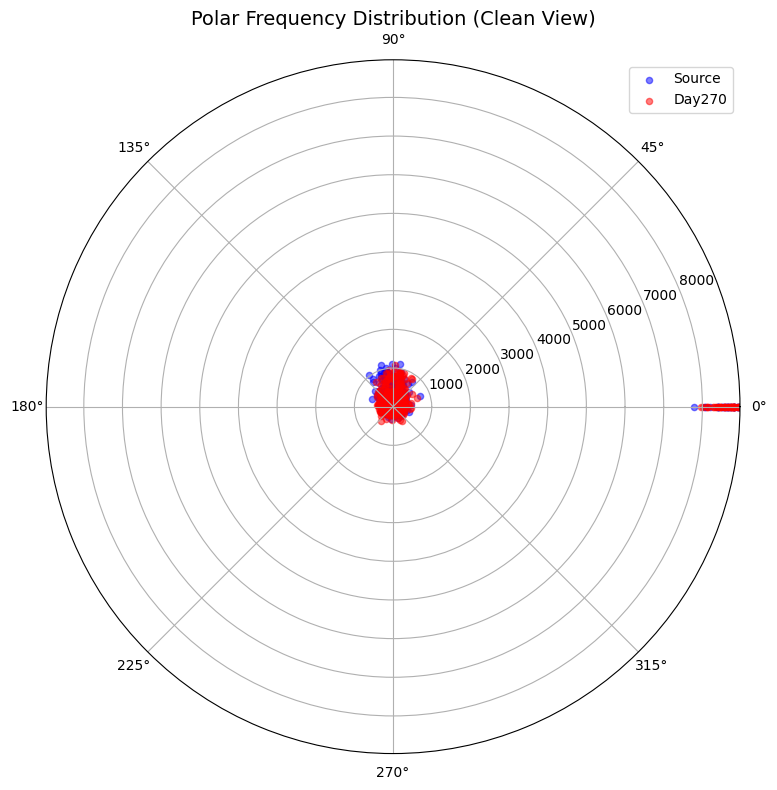

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 频域提取
# ======================
def get_spectrum(X, modes=64):   # 👉 降低频率维度
    if X.ndim == 2:
        X = X[:, np.newaxis, :]

    X = np.cos(X)
    X_fft = np.fft.rfft(X, axis=-1)[:, :, :modes]

    amp = np.abs(X_fft)
    phase = np.angle(X_fft)

    return amp, phase

# ======================
# 极坐标采样（重点优化）
# ======================
def sample_polar(amp, phase, sample_n=50):  # 👉 大幅减少样本
    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp = amp[idx, 0, :].flatten()
    phase = phase[idx, 0, :].flatten()

    # 再次降采样频率点
    step = 4  # 👉 每4个频率取1个
    amp = amp[::step]
    phase = phase[::step]

    return phase, amp

# ======================
# 参数
# ======================
modes = 64   # 👉 从256降到64（关键）

amp_s, phase_s = get_spectrum(X_s_cls, modes)
amp_t14, phase_t14 = get_spectrum(X_t14_cls, modes)
amp_t90, phase_t90 = get_spectrum(X_t90_cls, modes)
amp_t270, phase_t270 = get_spectrum(X_t270_cls, modes)

ps, as_ = sample_polar(amp_s, phase_s)
p14, a14 = sample_polar(amp_t14, phase_t14)
p90, a90 = sample_polar(amp_t90, phase_t90)
p270, a270 = sample_polar(amp_t270, phase_t270)

# ======================
# 极坐标图（清爽版）
# ======================
plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

ax.scatter(ps, as_, s=20, alpha=0.5, c='blue', label='Source')
# ax.scatter(p14, a14, s=20, alpha=0.5, c='orange', label='Day14')
# ax.scatter(p90, a90, s=20, alpha=0.5, c='green', label='Day90')
ax.scatter(p270, a270, s=20, alpha=0.5, c='red', label='Day270')

# 👉 自动缩放（去极端值）
all_amp = np.concatenate([as_, a14, a90, a270])
ax.set_rlim(0, np.percentile(all_amp, 98))

ax.set_title("Polar Frequency Distribution (Clean View)", fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 类别0 和26

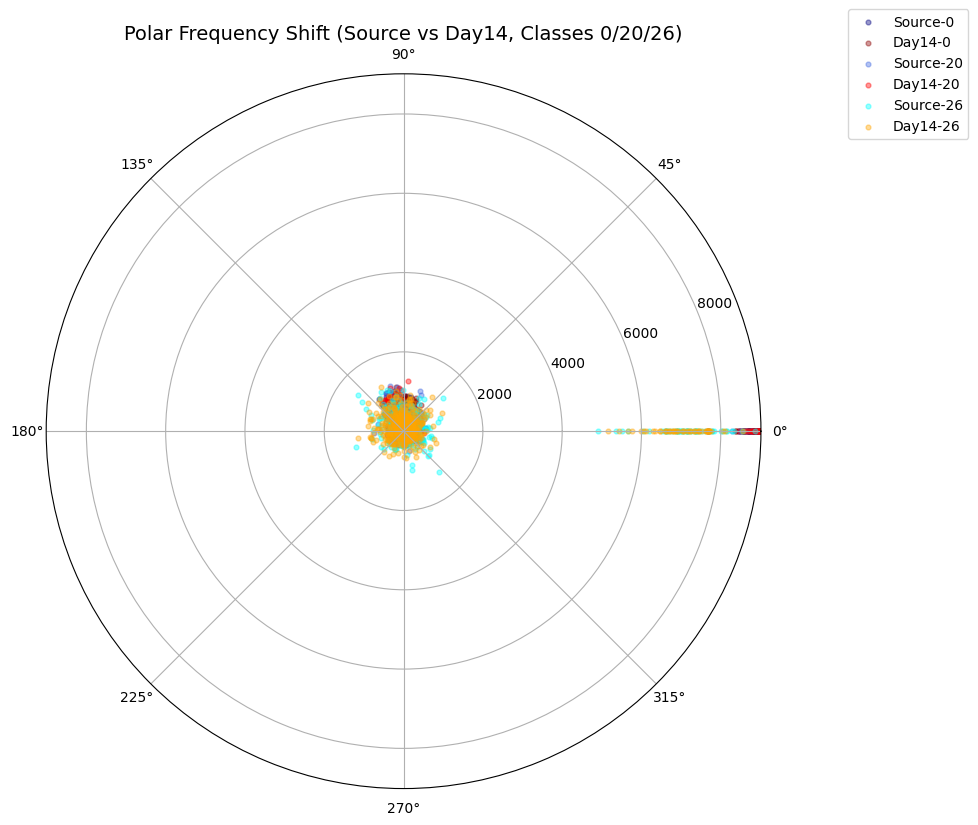

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载数据
# ======================
paths = {
    "Source": "./datasets/TemporalDrift/train.npz",
    "Day14": "./datasets/TemporalDrift/day14.npz"
}

data = {k: np.load(v) for k, v in paths.items()}
X = {k: v['X'] for k, v in data.items()}
y = {k: v['y'] for k, v in data.items()}

# ======================
# 2. 类别
# ======================
classes = [0, 20, 26]

# ======================
# 3. FFT
# ======================
def get_spectrum(X, modes=64):
    if X.ndim == 2:
        X = X[:, np.newaxis, :]

    X = np.cos(X)
    X_fft = np.fft.rfft(X, axis=-1)[:, :, :modes]

    amp = np.abs(X_fft)
    phase = np.angle(X_fft)

    return amp, phase

# ======================
# 4. 采样
# ======================
def sample_polar(amp, phase, sample_n=50):
    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp = amp[idx, 0, :].flatten()
    phase = phase[idx, 0, :].flatten()

    return phase[::4], amp[::4]

# ======================
# 5. 颜色（6组）
# ======================
colors = {
    "S_0": "navy",
    "S_20": "royalblue",
    "S_26": "cyan",
    "D_0": "darkred",
    "D_20": "red",
    "D_26": "orange"
}

# ======================
# 6. 极坐标图
# ======================
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

all_amp = []

modes = 64

for cls in classes:

    # ===== Source =====
    amp_s, phase_s = get_spectrum(X["Source"][y["Source"] == cls], modes)
    ps, as_ = sample_polar(amp_s, phase_s)

    ax.scatter(ps, as_, s=12, alpha=0.4,
               c=colors[f"S_{cls}"],
               label=f"Source-{cls}")

    all_amp.append(as_)

    # ===== Day14 =====
    amp_d, phase_d = get_spectrum(X["Day14"][y["Day14"] == cls], modes)
    pd, ad = sample_polar(amp_d, phase_d)

    ax.scatter(pd, ad, s=12, alpha=0.4,
               c=colors[f"D_{cls}"],
               label=f"Day14-{cls}")

    all_amp.append(ad)

# ======================
# 7. 美化
# ======================
all_amp = np.concatenate(all_amp)
ax.set_rlim(0, np.percentile(all_amp, 98))

ax.set_title("Polar Frequency Shift (Source vs Day14, Classes 0/20/26)", fontsize=14)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

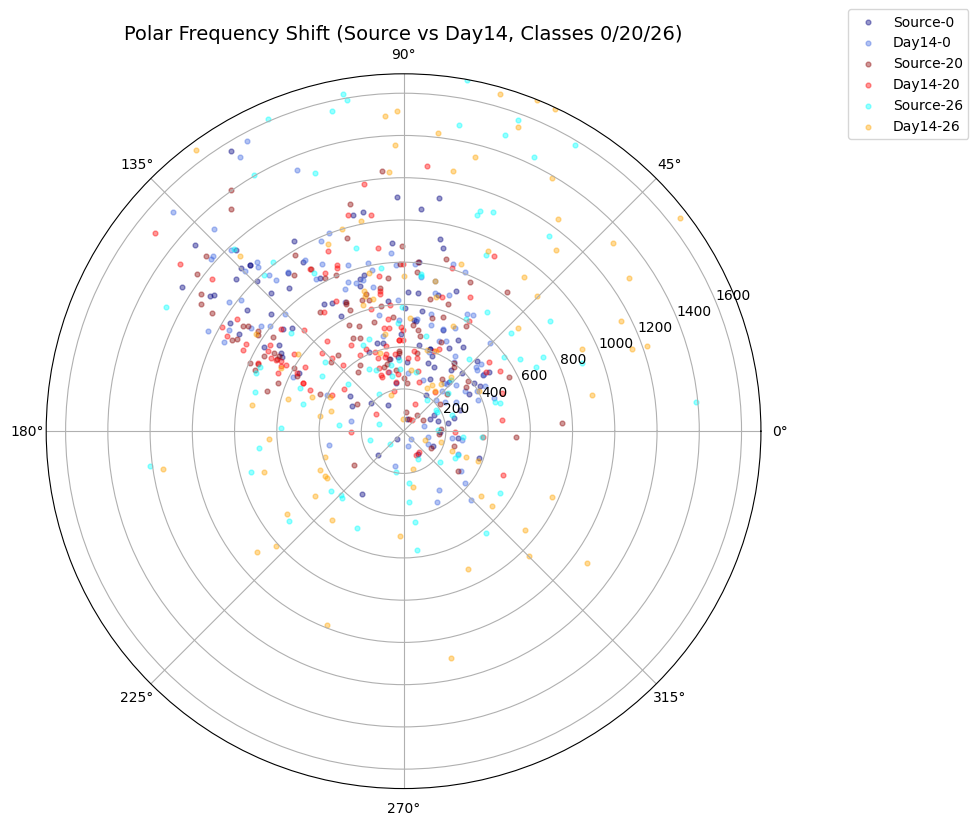

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载数据
# ======================
paths = {
    "Source": "./datasets/TemporalDrift/train.npz",
    "Day14": "./datasets/TemporalDrift/day14.npz"
}

data = {k: np.load(v) for k, v in paths.items()}
X = {k: v['X'] for k, v in data.items()}
y = {k: v['y'] for k, v in data.items()}

# ======================
# 2. 类别
# ======================
classes = [0, 20, 26]

# ======================
# 3. FFT
# ======================
def get_spectrum(X, modes=64):
    if X.ndim == 2:
        X = X[:, np.newaxis, :]

    X = np.cos(X)
    X_fft = np.fft.rfft(X, axis=-1)[:, :, :modes]

    amp = np.abs(X_fft)
    phase = np.angle(X_fft)

    return amp, phase

# ======================
# 4. 采样 只看主要部分
# ======================
def sample_polar(amp, phase, sample_n=50):
    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp = amp[idx, 0, :].flatten()
    phase = phase[idx, 0, :].flatten()

    # 降采样频率点
    amp = amp[::4]
    phase = phase[::4]

    # ======================
    # ⭐关键：只保留 r < 2000
    # ======================
    mask = amp < 2000
    amp = amp[mask]
    phase = phase[mask]

    return phase, amp
# 原始采样函数
# def sample_polar(amp, phase, sample_n=50):
#     B = amp.shape[0]
#     idx = np.random.choice(B, min(sample_n, B), replace=False)

#     amp = amp[idx, 0, :].flatten()
#     phase = phase[idx, 0, :].flatten()

#     return phase[::4], amp[::4]




# ======================
# 5. 颜色（6组）
# ======================
colors = {
    "S_0": "navy",
    "S_20": "darkred",
    "S_26": "cyan",
    "D_0": "royalblue",
    "D_20": "red",
    "D_26": "orange"
}

# ======================
# 6. 极坐标图
# ======================
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

all_amp = []

modes = 10

for cls in classes:

    # ===== Source =====
    amp_s, phase_s = get_spectrum(X["Source"][y["Source"] == cls], modes)
    ps, as_ = sample_polar(amp_s, phase_s)

    ax.scatter(ps, as_, s=12, alpha=0.4,
               c=colors[f"S_{cls}"],
               label=f"Source-{cls}")

    all_amp.append(as_)

    # ===== Day14 =====
    amp_d, phase_d = get_spectrum(X["Day14"][y["Day14"] == cls], modes)
    pd, ad = sample_polar(amp_d, phase_d)

    ax.scatter(pd, ad, s=12, alpha=0.4,
               c=colors[f"D_{cls}"],
               label=f"Day14-{cls}")

    all_amp.append(ad)

# ======================
# 7. 美化
# ======================
all_amp = np.concatenate(all_amp)
ax.set_rlim(0, np.percentile(all_amp, 98))

ax.set_title("Polar Frequency Shift (Source vs Day14, Classes 0/20/26)", fontsize=14)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## 查看失败的原因

In [2]:
import numpy as np

path = "./datasets/TemporalDrift/valid.npz"
data = np.load(path)
print(data.files)
# 比如查看前5条
print(data['X'][:5])
print(data['y'][:5])

['X', 'y']
[[ 1.00000000e-06 -3.95460592e-02  3.21044015e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.00000000e-06  2.70204408e-03  3.25281905e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.00000000e-06  4.70923019e-04 -1.70176076e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e-06 -2.25203084e-01  2.25667046e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e-06 -2.48122977e-01 -2.48175906e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[36. 59. 18. 79. 85.]


labels: [36. 59. 18. 79. 85.]


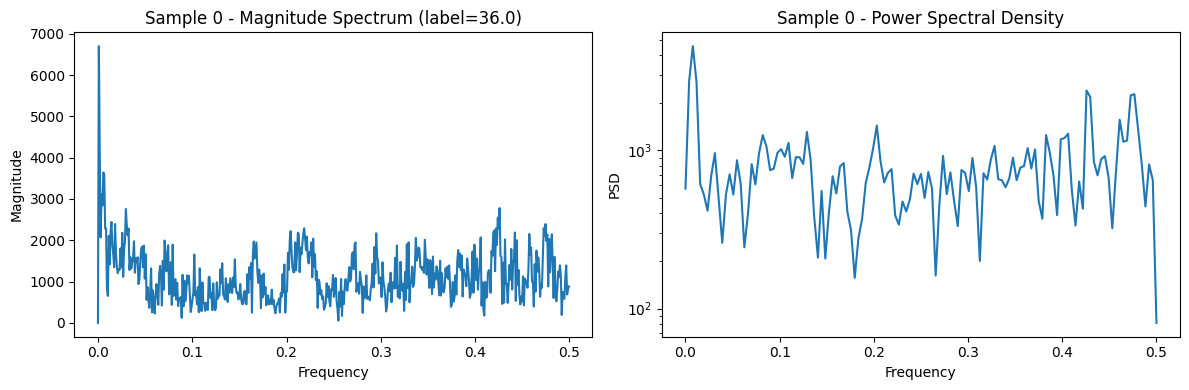

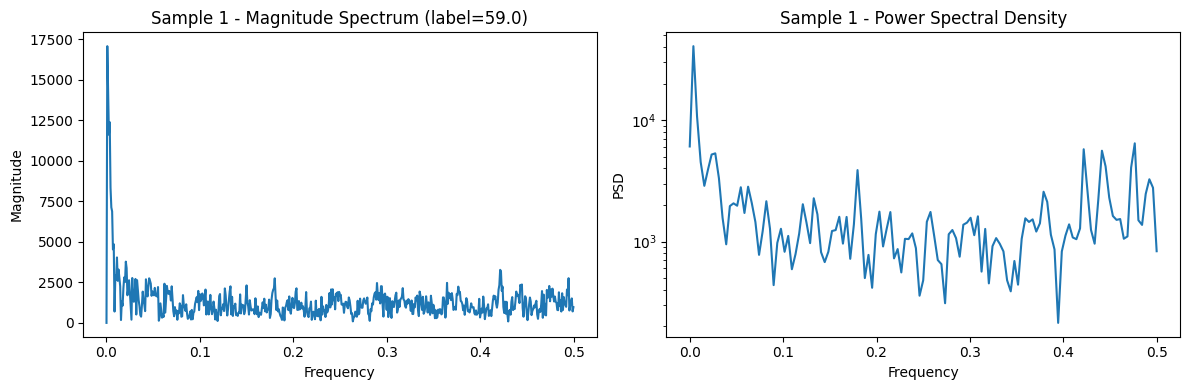

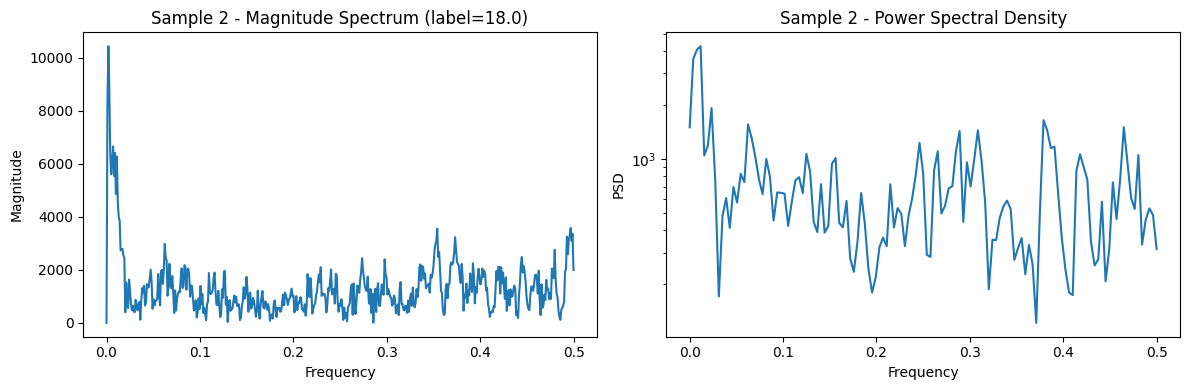

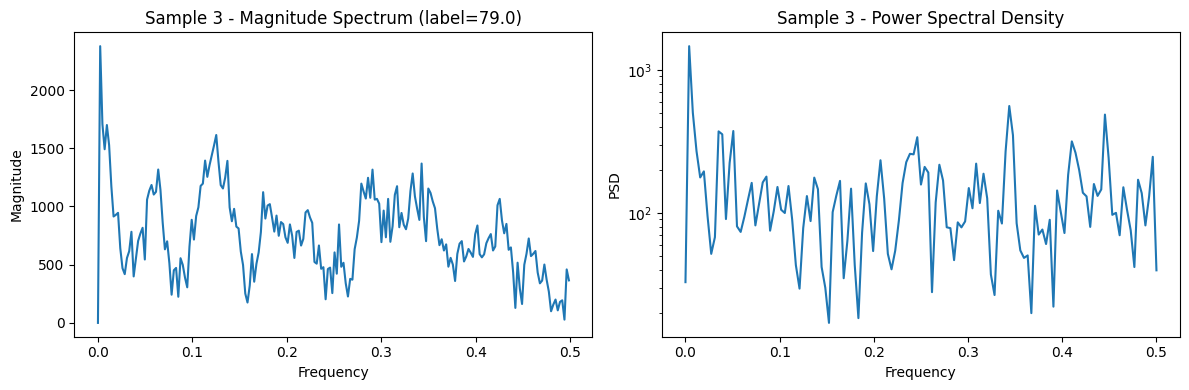

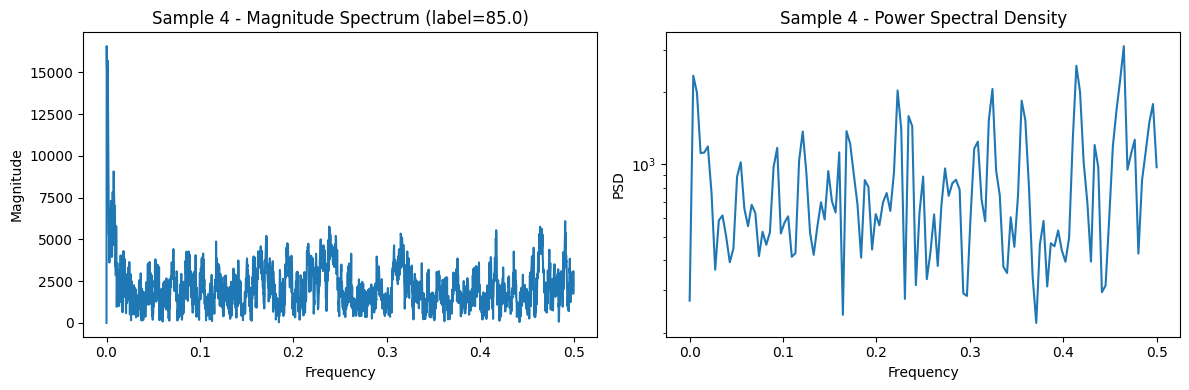

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ===== 加载数据 =====
path = "./datasets/TemporalDrift/valid.npz"
data = np.load(path)

X = data['X'][:5]   # 前5条
y = data['y'][:5]

print("labels:", y)

# ===== 画图 =====
for i, seq in enumerate(X):
    # ---- 去掉尾部全0 padding ----
    non_zero_idx = np.where(seq != 0)[0]
    if len(non_zero_idx) == 0:
        continue
    seq = seq[:non_zero_idx[-1] + 1]

    # ---- 去均值（很重要）----
    seq = seq - np.mean(seq)

    N = len(seq)

    # ===== FFT =====
    fft_vals = np.fft.fft(seq)
    mag = np.abs(fft_vals)

    # 只取一半（对称）
    freqs = np.fft.fftfreq(N)
    pos_mask = freqs >= 0

    freqs = freqs[pos_mask]
    mag = mag[pos_mask]

    # ===== PSD（Welch）=====
    freqs_psd, psd = welch(seq, nperseg=min(256, N))

    # ===== 画图 =====
    plt.figure(figsize=(12, 4))

    # ---- 幅度谱 ----
    plt.subplot(1, 2, 1)
    plt.plot(freqs, mag)
    plt.title(f"Sample {i} - Magnitude Spectrum (label={y[i]})")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")

    # ---- PSD ----
    plt.subplot(1, 2, 2)
    plt.semilogy(freqs_psd, psd)
    plt.title(f"Sample {i} - Power Spectral Density")
    plt.xlabel("Frequency")
    plt.ylabel("PSD")

    plt.tight_layout()
    plt.show()

## 只做方向呢？

labels: [36. 59. 18. 79. 85.]


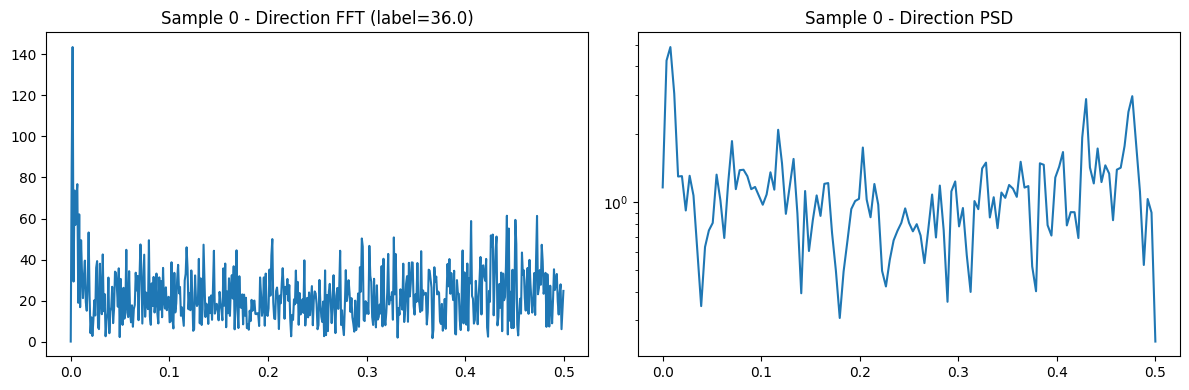

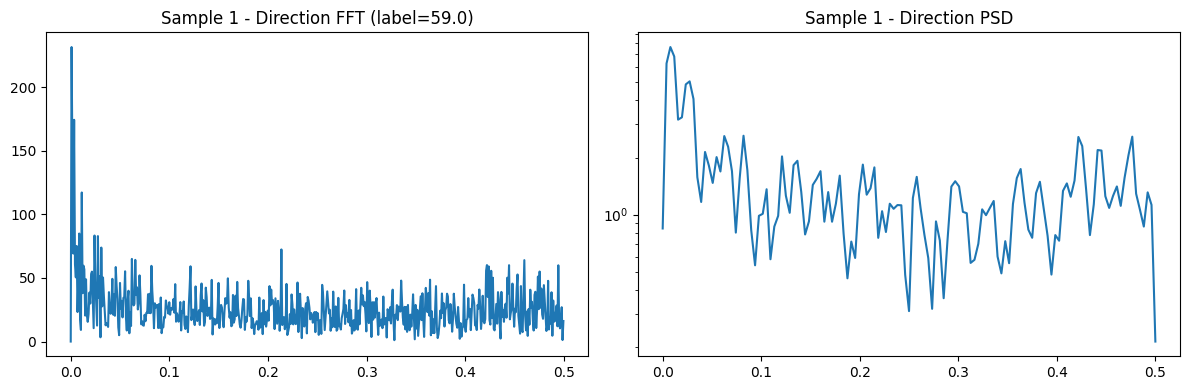

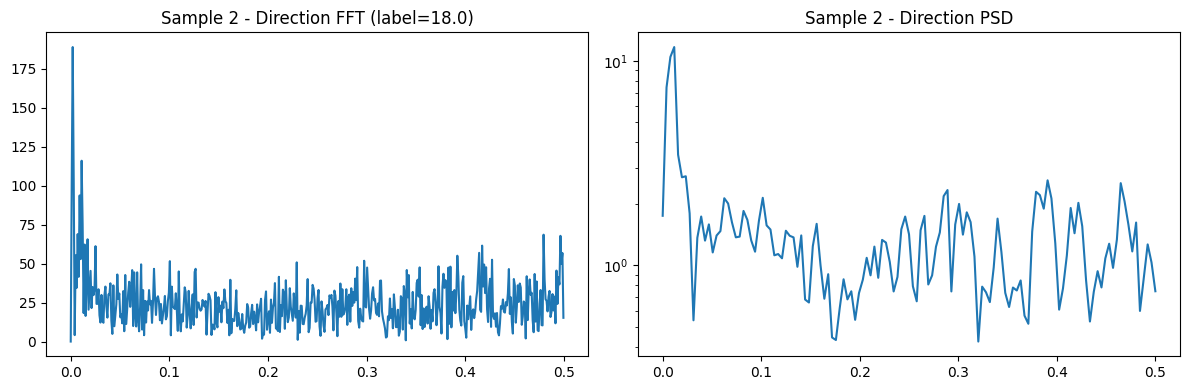

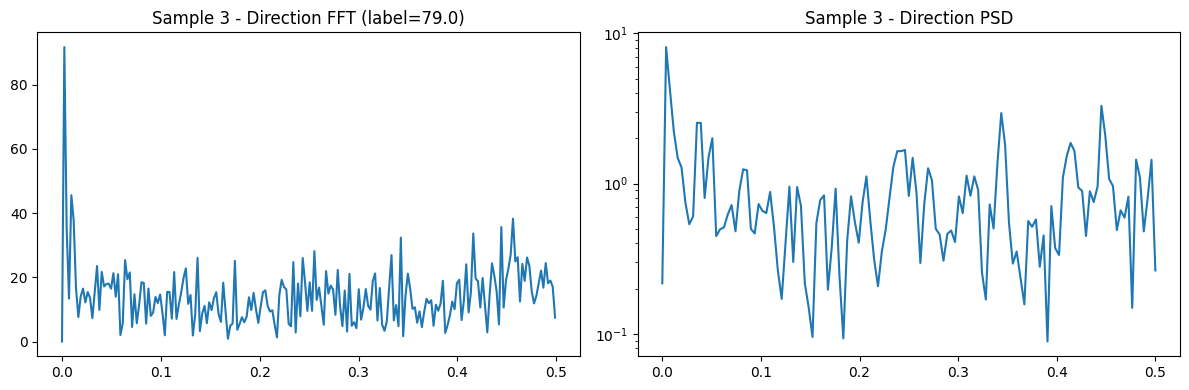

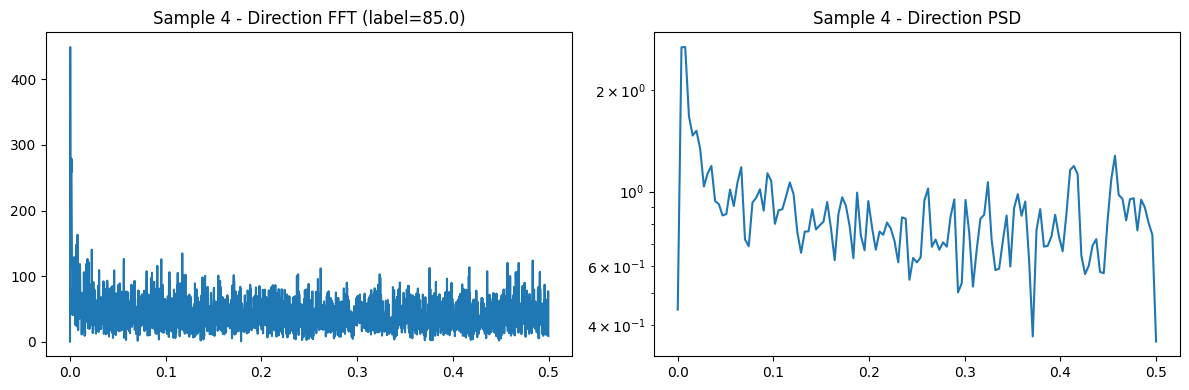

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ===== 加载数据 =====
path = "./datasets/TemporalDrift/valid.npz"
data = np.load(path)

X = data['X'][:5]
y = data['y'][:5]

print("labels:", y)

for i, seq in enumerate(X):
    # ===== 1️⃣ 去掉padding =====
    non_zero_idx = np.where(seq != 0)[0]
    if len(non_zero_idx) == 0:
        continue
    seq = seq[:non_zero_idx[-1] + 1]

    # ===== 2️⃣ 只保留方向 =====
    direction = np.sign(seq)

    # ⚠️ 可选：去掉0（如果你认为padding已经裁干净）
    # direction = direction[direction != 0]

    # ===== 3️⃣ 去均值（关键）=====
    direction = direction - np.mean(direction)

    N = len(direction)

    # ===== FFT =====
    fft_vals = np.fft.fft(direction)
    mag = np.abs(fft_vals)

    freqs = np.fft.fftfreq(N)
    pos_mask = freqs >= 0

    freqs = freqs[pos_mask]
    mag = mag[pos_mask]

    # ===== PSD =====
    freqs_psd, psd = welch(direction, nperseg=min(256, N))

    # ===== 画图 =====
    plt.figure(figsize=(12, 4))

    # 幅度谱
    plt.subplot(1, 2, 1)
    plt.plot(freqs, mag)
    plt.title(f"Sample {i} - Direction FFT (label={y[i]})")

    # PSD
    plt.subplot(1, 2, 2)
    plt.semilogy(freqs_psd, psd)
    plt.title(f"Sample {i} - Direction PSD")

    plt.tight_layout()
    plt.show()

Final shape: (194, 1, 590)


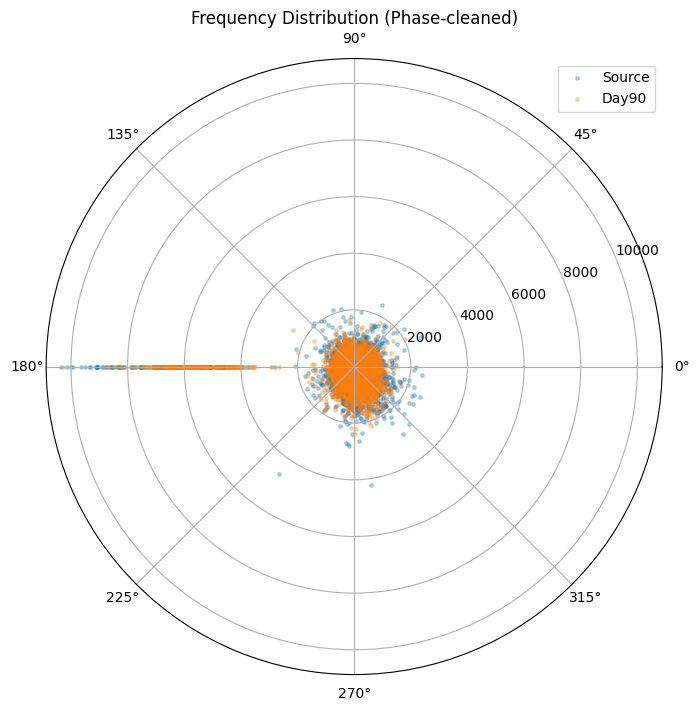

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载数据
# ======================
path = "./datasets/TemporalDrift/train.npz"
path90 = "./datasets/TemporalDrift/day90.npz"

data = np.load(path)
data90 = np.load(path90)

X_s, y_s = data['X'], data['y']
X_t90, y_t90 = data90['X'], data90['y']

# ======================
# 2. 只取类别 0
# ======================
cls = 0

X_s_cls = X_s[y_s == cls]
X_t90_cls = X_t90[y_t90 == cls]

# ======================
# 3. 去 padding
# ======================
def remove_zero_padding(X):
    cleaned = []

    for x in X:

        if x.ndim == 1:
            idx = np.where(x != 0)[0]
            if len(idx) == 0:
                continue
            last = idx[-1]
            cleaned.append(x[:last + 1])

        elif x.ndim == 2:
            idx = np.where(np.abs(x).sum(axis=0) != 0)[0]
            if len(idx) == 0:
                continue
            last = idx[-1]
            cleaned.append(x[:, :last + 1])

        else:
            raise ValueError(x.shape)

    return np.array(cleaned, dtype=object)

X_s_cls = remove_zero_padding(X_s_cls)
X_t90_cls = remove_zero_padding(X_t90_cls)

# ======================
# 4. 对齐长度
# ======================
def pad_or_crop(X, L):
    out = []

    for x in X:

        if x.ndim == 1:
            if x.shape[0] >= L:
                x = x[:L]
            else:
                x = np.pad(x, (0, L - x.shape[0]))
            x = x[np.newaxis, :]
            out.append(x)

        elif x.ndim == 2:
            if x.shape[-1] >= L:
                x = x[:, :L]
            else:
                pad = np.zeros((x.shape[0], L - x.shape[-1]))
                x = np.concatenate([x, pad], axis=-1)
            out.append(x)

    return np.stack(out)

min_len = min(
    min([x.shape[-1] for x in X_s_cls]),
    min([x.shape[-1] for x in X_t90_cls])
)

X_s_cls = pad_or_crop(X_s_cls, min_len)
X_t90_cls = pad_or_crop(X_t90_cls, min_len)

print("Final shape:", X_s_cls.shape)

# ======================
# 5. FFT（核心）
# ======================
def get_spectrum(X, modes=256):
    if X.ndim == 2:
        X = X[:, np.newaxis, :]

    X_fft = np.fft.rfft(X, axis=-1)

    amp = np.abs(X_fft[:, :, :modes])
    phase = np.angle(X_fft[:, :, :modes])

    return amp, phase

modes = 256

amp_s, phase_s = get_spectrum(X_s_cls, modes)
amp_t90, phase_t90 = get_spectrum(X_t90_cls, modes)

# ======================
# ⭐ 6. 关键修复：过滤低能量点（非常重要）
# ======================
def sample_polar(amp, phase, sample_n=200, amp_thresh=30):
    """
    只保留“有意义的频率点”
    避免 phase noise 塌缩
    """

    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp_s = amp[idx, 0, :]
    phase_s = phase[idx, 0, :]

    amp_flat = amp_s.flatten()
    phase_flat = phase_s.flatten()

    # ===== 关键：过滤低能量 =====
    mask = amp_flat > np.percentile(amp_flat, amp_thresh)

    return phase_flat[mask], amp_flat[mask]


# Source
ps, as_ = sample_polar(amp_s, phase_s)

# Day90
p90, a90 = sample_polar(amp_t90, phase_t90)

# ======================
# 7. 频域分布图（正确版本）
# ======================
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

ax.scatter(ps, as_, s=6, alpha=0.3, label='Source')
ax.scatter(p90, a90, s=6, alpha=0.3, label='Day90')

ax.set_title("Frequency Distribution (Phase-cleaned)")
ax.legend()

plt.show()

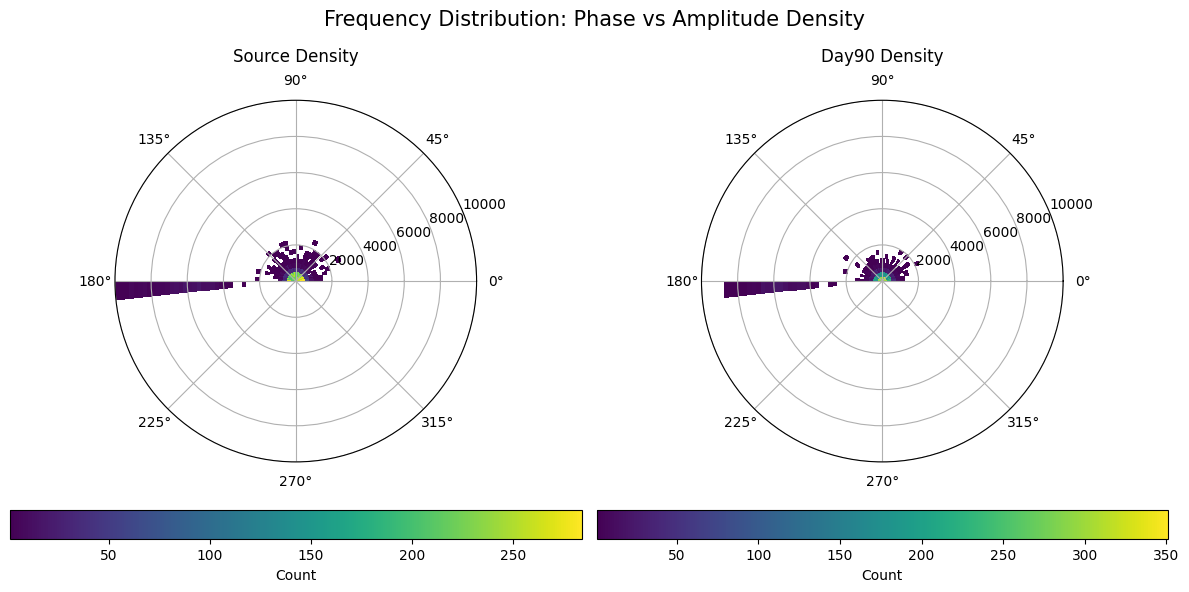

In [9]:
# ======================
# 7. 频域分布图（密度图版本）
# ======================
plt.figure(figsize=(12, 6))

# --- 绘制 Source (左侧) ---
ax1 = plt.subplot(121, projection='polar')

# 使用 hist2d 绘制 2D 直方图
# bins: 网格数量 (角度分辨率, 幅度分辨率)
# cmap: 颜色映射，'viridis' 或 'plasma' 效果较好
h1 = ax1.hist2d(ps, as_, bins=[60, 40], range=[[0, 2*np.pi], [0, 10000]],
                cmap='viridis', cmin=1) # cmin=1 隐藏没有点的格子

ax1.set_title("Source Density", va='bottom', fontsize=12)
# 添加颜色条
plt.colorbar(h1[3], ax=ax1, orientation='horizontal', pad=0.1, label='Count')


# --- 绘制 Day90 (右侧) ---
ax2 = plt.subplot(122, projection='polar')

# 关键：确保 Day90 的 bins 和 range 与 Source 完全一致，以便对比
h2 = ax2.hist2d(p90, a90, bins=[60, 40], range=[[0, 2*np.pi], [0, 10000]],
                cmap='viridis', cmin=1)

ax2.set_title("Day90 Density", va='bottom', fontsize=12)
plt.colorbar(h2[3], ax=ax2, orientation='horizontal', pad=0.1, label='Count')

plt.suptitle("Frequency Distribution: Phase vs Amplitude Density", fontsize=15)
plt.tight_layout()
plt.show()

# 主成分分析

PC1 解释方差比例: 0.0471
PC2 解释方差比例: 0.0307


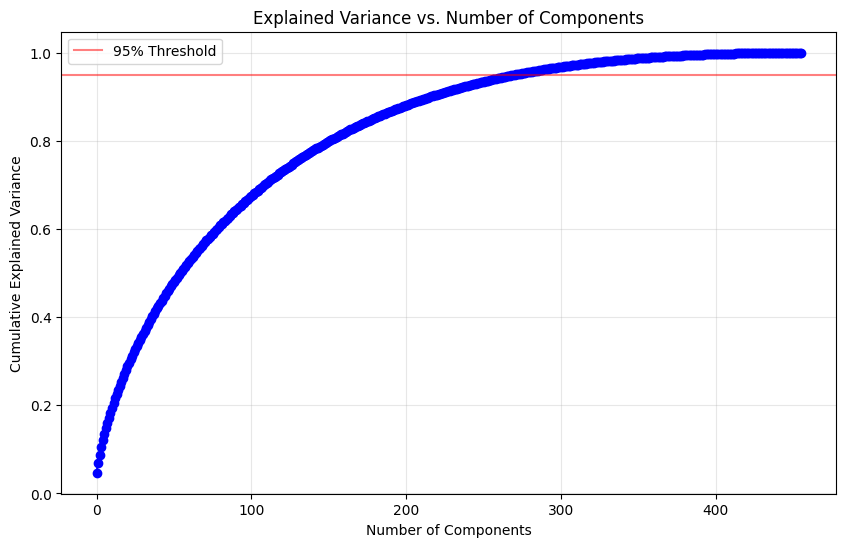

前2个主成分解释方差: 6.81%
前10个主成分解释方差: 18.35%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ======================
# 1. 数据准备 (沿用之前的加载部分)
# ======================
path = "./datasets/TemporalDrift/train.npz"
path90 = "./datasets/TemporalDrift/day90.npz"

data = np.load(path)
data90 = np.load(path90)

X_s, y_s = data['X'], data['y']
X_t90, y_t90 = data90['X'], data90['y']

# 只取类别 0
cls = 0
X_s_cls = X_s[y_s == cls]
X_t90_cls = X_t90[y_t90 == cls]

# 去 padding (复用你之前的函数)
def remove_zero_padding(X):
    cleaned = []
    for x in X:
        if x.ndim == 1:
            idx = np.where(x != 0)[0]
            if len(idx) == 0: continue
            cleaned.append(x[:idx[-1]+1])
        elif x.ndim == 2:
            idx = np.where(np.abs(x).sum(axis=0) != 0)[0]
            if len(idx) == 0: continue
            cleaned.append(x[:, :idx[-1]+1])
    return np.array(cleaned, dtype=object)

X_s_cls = remove_zero_padding(X_s_cls)
X_t90_cls = remove_zero_padding(X_t90_cls)

# 对齐长度 (复用你之前的函数)
def pad_or_crop(X, L):
    out = []
    for x in X:
        if x.ndim == 1:
            x = x[:L] if x.shape[0] >= L else np.pad(x, (0, L-x.shape[0]))
            out.append(x[np.newaxis, :])
        elif x.ndim == 2:
            x = x[:, :L] if x.shape[-1] >= L else np.concatenate([x, np.zeros((x.shape[0], L-x.shape[-1]))], axis=-1)
            out.append(x)
    return np.stack(out)

min_len = min(min([x.shape[-1] for x in X_s_cls]), min([x.shape[-1] for x in X_t90_cls]))
X_s_cls = pad_or_crop(X_s_cls, min_len)   # Shape: (N_s, C, L)
X_t90_cls = pad_or_crop(X_t90_cls, min_len) # Shape: (N_t, C, L)

# ======================
# 2. 数据展平与标准化
# PCA需要二维输入 (Samples, Features)
# ======================
# 将 (Batch, Channel, Length) 展平为 (Batch, Channel * Length)
X_s_flat = X_s_cls.reshape(X_s_cls.shape[0], -1)
X_t90_flat = X_t90_cls.reshape(X_t90_cls.shape[0], -1)

# 合并数据以便统一标准化 (可选，但推荐)
X_combined = np.vstack((X_s_flat, X_t90_flat))

# 标准化：PCA对尺度非常敏感，必须做 Z-score
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# 切分回两组
X_s_proc = X_combined_scaled[:X_s_flat.shape[0]]
X_t90_proc = X_combined_scaled[X_s_flat.shape[0]:]

# ======================
# 3. PCA 计算
# ======================
# 我们可以先看累计方差贡献率，决定保留多少维度
pca_full = PCA()
pca_full.fit(X_combined_scaled)

# 实际降维用于绘图 (2D)
pca = PCA(n_components=2)
proj_s = pca.fit_transform(X_s_proc)
proj_t90 = pca.fit_transform(X_t90_proc)

print(f"PC1 解释方差比例: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 解释方差比例: {pca.explained_variance_ratio_[1]:.4f}")

# ======================
# 4. 可视化：PCA 散点图
# ======================
# 拟合 PCA
pca_full = PCA()
pca_full.fit(X_combined_scaled)

# --- 修正后的绘图部分 ---
plt.figure(figsize=(10, 6))

# 绘制累计解释方差比
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='-', alpha=0.5, label='95% Threshold') # 可选：画出95%阈值线
plt.legend()

plt.show()

# ======================
# 5. 打印关键指标
# ======================
explained_variance = pca_full.explained_variance_ratio_
print(f"前2个主成分解释方差: {np.sum(explained_variance[:2]):.2%}")
print(f"前10个主成分解释方差: {np.sum(explained_variance[:10]):.2%}")

Source 类别 0 样本数: 194
Day90 类别 0 样本数: 262
正在提取频域特征...


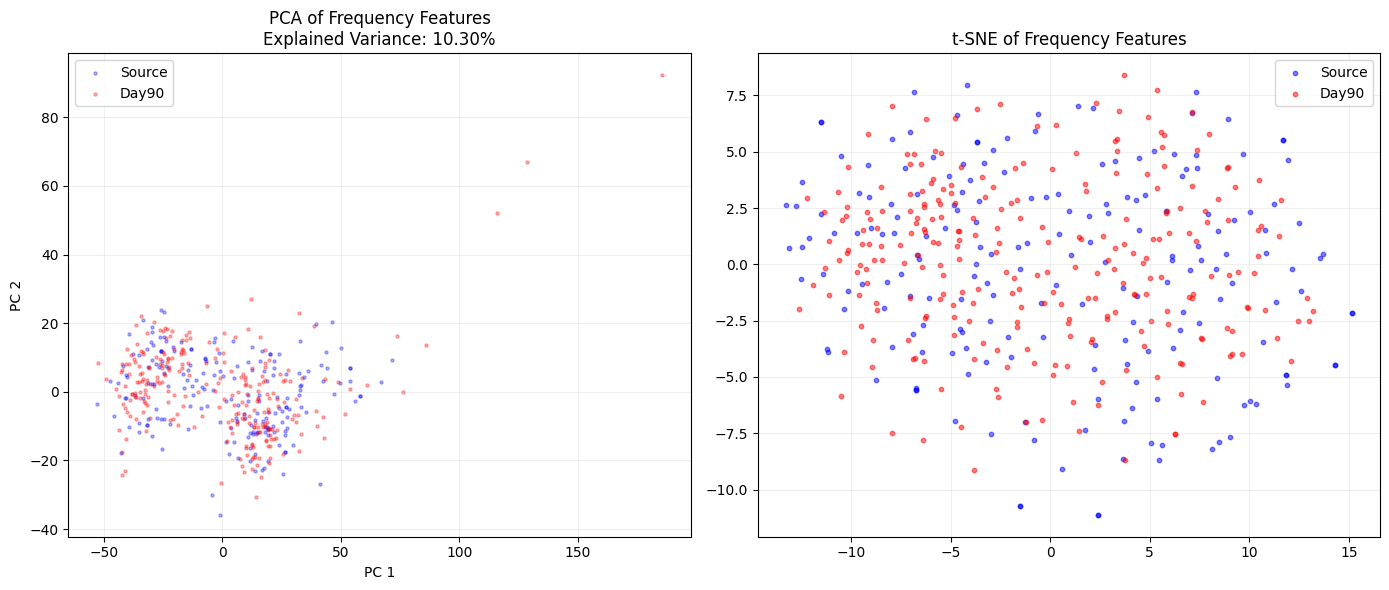

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ======================
# 1. 数据准备与对齐
# ======================
path = "./datasets/TemporalDrift/train.npz"
path90 = "./datasets/TemporalDrift/day90.npz"

data = np.load(path)
data90 = np.load(path90)

X_s, y_s = data['X'], data['y']
X_t90, y_t90 = data90['X'], data90['y']

# --- 修复核心：强制对齐维度 ---
# 检查 Day90 的样本数和标签数是否一致
min_len_90 = min(X_t90.shape[0], y_t90.shape[0])
if X_t90.shape[0] != y_t90.shape[0]:
    print(f"⚠️ 警告：Day90 数据维度不匹配！X: {X_t90.shape[0]}, y: {y_t90.shape[0]}")
    print(f"👉 正在自动截断至最小长度: {min_len_90} ...")
    X_t90 = X_t90[:min_len_90]
    y_t90 = y_t90[:min_len_90]

# 同样检查 Source 数据（以防万一）
min_len_s = min(X_s.shape[0], y_s.shape[0])
if X_s.shape[0] != y_s.shape[0]:
    X_s = X_s[:min_len_s]
    y_s = y_s[:min_len_s]

# 选择特定类别（例如类别 0）
cls = 0
X_s_cls = X_s[y_s == cls]
X_t90_cls = X_t90[y_t90 == cls]

# 打印筛选后的数量
print(f"Source 类别 {cls} 样本数: {len(X_s_cls)}")
print(f"Day90 类别 {cls} 样本数: {len(X_t90_cls)}")

# ======================
# 2. 频域特征提取 (FFT)
# ======================
def get_freq_features(X):
    features = []
    for x in X:
        # 如果是双通道，取平均或合并；这里假设是单通道或取第一通道
        if x.ndim > 1:
            sig = x[0, :] 
        else:
            sig = x
            
        # 去直流分量
        sig = sig - np.mean(sig)
        
        # FFT
        fft_val = np.fft.fft(sig)
        fft_val = fft_val[:len(fft_val)//2] # 取正频率
        
        # 幅度与相位
        amp = np.abs(fft_val)
        phase = np.angle(fft_val)
        
        # 拼接特征
        feat = np.concatenate((amp, phase))
        features.append(feat)
    return np.array(features)

print("正在提取频域特征...")
feat_s = get_freq_features(X_s_cls)
feat_t90 = get_freq_features(X_t90_cls)

# ======================
# 3. 数据标准化
# ======================
# 合并数据以便统一标准化
X_combined = np.vstack((feat_s, feat_t90))
y_combined = np.array([0]*len(feat_s) + [1]*len(feat_t90))

# 标准化 (非常重要，因为幅度和相位的量纲不同)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# ======================
# 4. 可视化：PCA (线性)
# ======================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[y_combined==0, 0], X_pca[y_combined==0, 1], c='blue', alpha=0.3, s=5, label='Source')
plt.scatter(X_pca[y_combined==1, 0], X_pca[y_combined==1, 1], c='red', alpha=0.3, s=5, label='Day90')
plt.title(f'PCA of Frequency Features\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, alpha=0.2)

# ======================
# 5. 可视化：t-SNE (非线性)
# ======================
# 注意：t-SNE 计算量较大，如果数据量超过1万，建议先随机采样
max_samples = 2000 
if len(X_scaled) > max_samples * 2:
    print(f"数据量较大，正在随机采样 {max_samples} 个样本进行 t-SNE...")
    indices = np.random.choice(len(X_scaled), max_samples * 2, replace=False)
    X_tsne_in = X_scaled[indices]
    y_tsne_in = y_combined[indices]
else:
    X_tsne_in = X_scaled
    y_tsne_in = y_combined

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_in)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[y_tsne_in==0, 0], X_tsne[y_tsne_in==0, 1], c='blue', alpha=0.5, s=10, label='Source')
plt.scatter(X_tsne[y_tsne_in==1, 0], X_tsne[y_tsne_in==1, 1], c='red', alpha=0.5, s=10, label='Day90')
plt.title('t-SNE of Frequency Features')
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 看看相位k

正在提取相位特征...


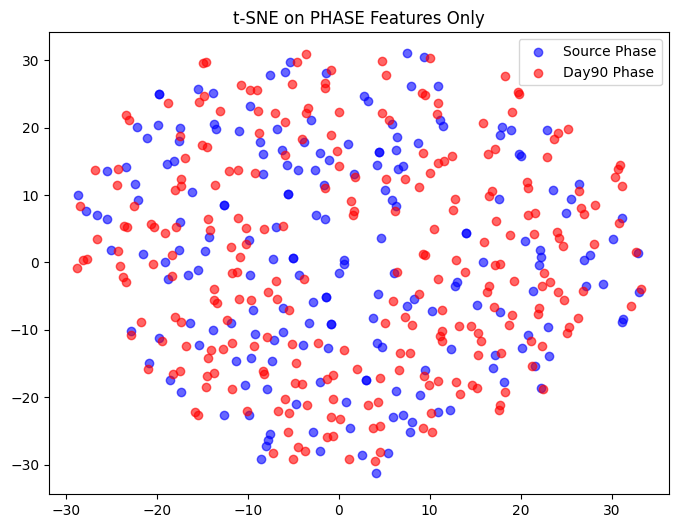

In [15]:
# ... (前面的加载代码保持不变) ...

# 假设我们已经有了 X_s_cls 和 X_t90_cls (时域信号)

def extract_phase_features(X):
    # 对每个样本做 FFT
    freq_features = []
    for x in X:
        # 如果是多通道，可能需要展平或逐通道处理，这里假设单通道或取平均
        if x.ndim > 1:
            x = x.mean(axis=0) 
        
        # FFT
        fft_val = np.fft.fft(x)
        # 取相位，并展平
        phase = np.angle(fft_val)
        freq_features.append(phase)
    return np.array(freq_features)

print("正在提取相位特征...")
phase_s = extract_phase_features(X_s_cls)
phase_t90 = extract_phase_features(X_t90_cls)

# 标准化
scaler = StandardScaler()
phase_combined = np.vstack((phase_s, phase_t90))
phase_combined = scaler.fit_transform(phase_combined)

# t-SNE 可视化相位
tsne_phase = TSNE(n_components=2, random_state=42)
Z_phase = tsne_phase.fit_transform(phase_combined)

plt.figure(figsize=(8, 6))
plt.scatter(Z_phase[:len(phase_s), 0], Z_phase[:len(phase_s), 1], c='blue', label='Source Phase', alpha=0.6)
plt.scatter(Z_phase[len(phase_s):, 0], Z_phase[len(phase_s):, 1], c='red', label='Day90 Phase', alpha=0.6)
plt.title("t-SNE on PHASE Features Only")
plt.legend()
plt.show()

## 多类别：

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ======================
# 1. 数据加载与对齐
# ======================
path = "./datasets/TemporalDrift/train.npz"
path90 = "./datasets/TemporalDrift/day90.npz"

data = np.load(path)
data90 = np.load(path90)

X_s, y_s = data['X'], data['y']
X_t90, y_t90 = data90['X'], data90['y']

# 强制对齐 Day90 维度
min_len_90 = min(X_t90.shape[0], y_t90.shape[0])
X_t90 = X_t90[:min_len_90]
y_t90 = y_t90[:min_len_90]

# ======================
# 2. 频域特征提取函数
# ======================
def extract_freq_features(X):
    features = []
    for x in X:
        # 去除 padding
        if x.ndim == 2:
            non_zero_idx = np.where(np.any(x != 0, axis=1))[0]
            if len(non_zero_idx) == 0: continue
            x = x[:non_zero_idx[-1]+1]
        else:
            non_zero_idx = np.where(x != 0)[0]
            if len(non_zero_idx) == 0: continue
            x = x[:non_zero_idx[-1]+1]
            
        # FFT
        fft_vals = np.fft.fft(x)
        magnitude = np.abs(fft_vals)
        phase = np.angle(fft_vals)
        
        # 只取前半部分 (正频率)
        half = len(magnitude) // 2
        mag_half = magnitude[:half]
        phase_half = phase[:half]
        
        # 拼接特征
        feat = np.concatenate((mag_half, phase_half))
        features.append(feat)
    return np.array(features)

print("正在提取频域特征 (幅度+相位)...")

# 提取三类数据：
# 1. Source 类别 0
# 2. Day90 类别 0
# 3. Source 类别 1 (用来做对比)

cls_0_src = X_s[y_s == 0]
cls_0_90 = X_t90[y_t90 == 0]
cls_1_src = X_s[y_s == 1] # 新增：类别 1

# 提取特征
feat_0_src = extract_freq_features(cls_0_src)
feat_0_90 = extract_freq_features(cls_0_90)
feat_1_src = extract_freq_features(cls_1_src)

print(f"类别 0 (Source) 样本数: {len(feat_0_src)}")
print(f"类别 0 (Day90) 样本数: {len(feat_0_90)}")
print(f"类别 1 (Source) 样本数: {len(feat_1_src)}")

# 合并所有特征
X_combined = np.vstack((feat_0_src, feat_0_90, feat_1_src))

# 创建标签用于绘图
y_plot = (['Class 0 (Source)'] * len(feat_0_src) + 
          ['Class 0 (Day90)'] * len(feat_0_90) + 
          ['Class 1 (Source)'] * len(feat_1_src))

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# ======================
# 3. 可视化 (PCA & t-SNE)
# ======================
plt.figure(figsize=(16, 7))

# --- PCA ---
plt.subplot(1, 2, 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = {'Class 0 (Source)': 'blue', 'Class 0 (Day90)': 'red', 'Class 1 (Source)': 'green'}
for label in colors:
    mask = np.array(y_plot) == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[label], label=label, alpha=0.6, s=10)

正在提取频域特征 (幅度+相位)...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (194,) + inhomogeneous part.

In [ ]:
import numpy as np

path = "./datasets/TemporalDrift/tam_valid.npz"
data = np.load(path)
print(data.files)